In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 6)

arima_m = pd.read_csv('../results/arima_metrics.csv')
prophet_m = pd.read_csv('../results/prophet_metrics.csv')
lstm_m = pd.read_csv('../results/lstm_metrics.csv')

metrics = pd.concat([arima_m, prophet_m, lstm_m], ignore_index=True)
print(metrics.to_string(index=False))

          model         MAE        RMSE      MAPE
 ARIMA(3, 1, 3) 5837.345039 6654.216152 19.991757
Prophet (Tuned) 2461.389078 3328.249718  7.412590
 LSTM (PyTorch) 1484.174824 1951.699221  4.754864


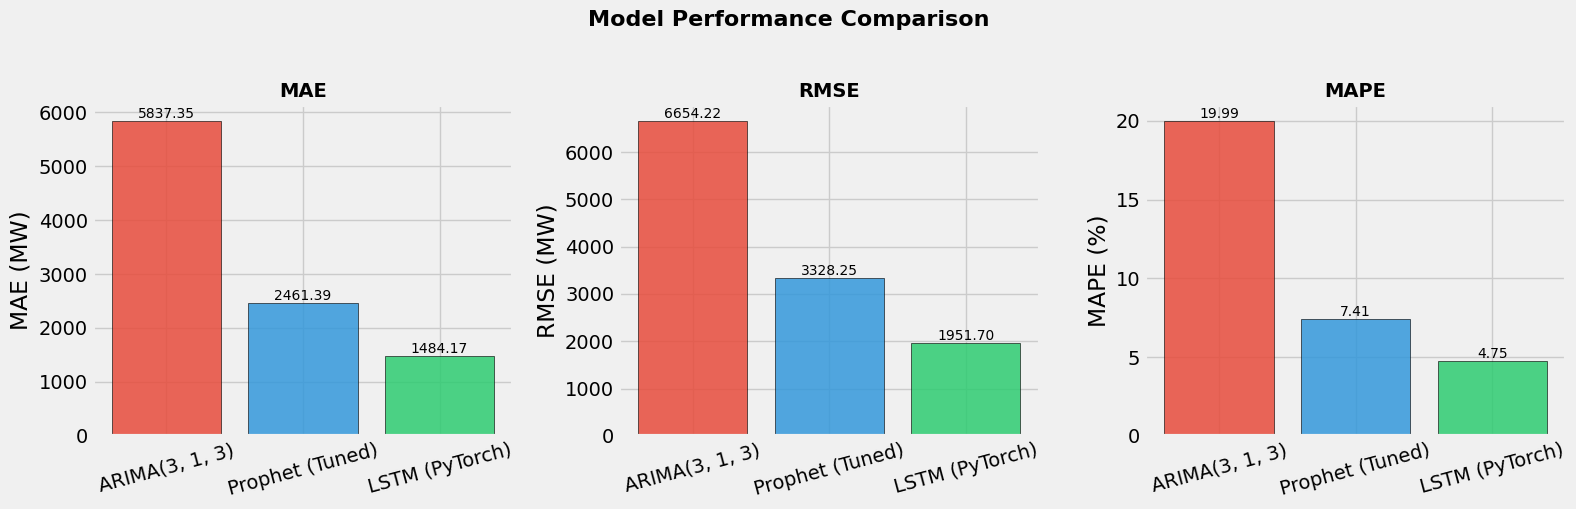

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, metric in enumerate(['MAE', 'RMSE', 'MAPE']):
    bars = axes[i].bar(metrics['model'], metrics[metric], color=colors, edgecolor='black', alpha=0.85)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylabel(f'{metric} {"(MW)" if metric != "MAPE" else "(%)"}')
    axes[i].tick_params(axis='x', rotation=15)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

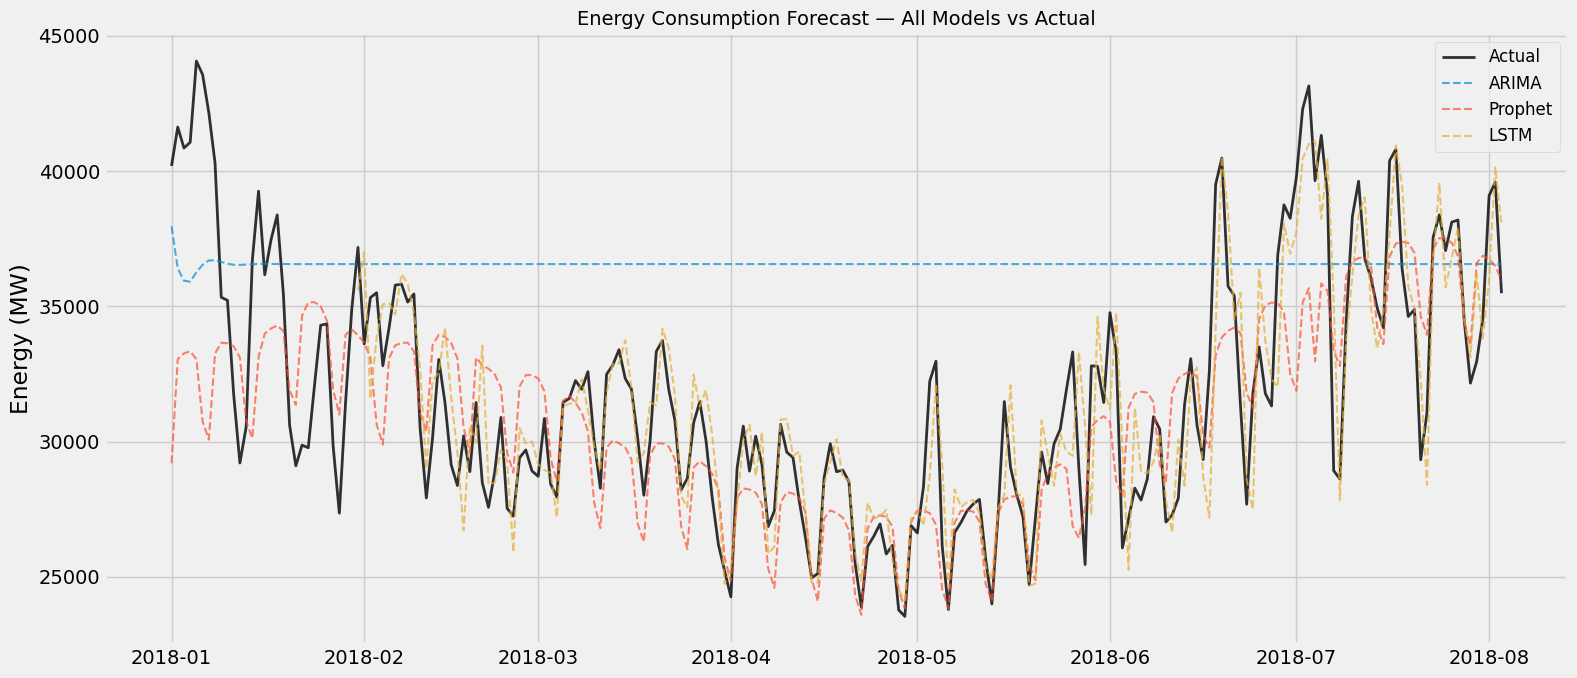

In [3]:
arima_r = pd.read_csv('../results/arima_results.csv', index_col=0, parse_dates=True)
prophet_r = pd.read_csv('../results/prophet_results.csv', index_col=0, parse_dates=True)
lstm_r = pd.read_csv('../results/lstm_results.csv', index_col=0, parse_dates=True)

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(arima_r.index, arima_r['actual'], label='Actual', color='black', linewidth=2, alpha=0.8)
ax.plot(arima_r.index, arima_r['predicted'], label='ARIMA', linestyle='--', alpha=0.7, linewidth=1.5)
ax.plot(prophet_r.index, prophet_r['predicted'], label='Prophet', linestyle='--', alpha=0.7, linewidth=1.5)
ax.plot(lstm_r.index, lstm_r['predicted'], label='LSTM', linestyle='--', alpha=0.7, linewidth=1.5)

ax.set_title('Energy Consumption Forecast — All Models vs Actual', fontsize=14)
ax.set_ylabel('Energy (MW)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

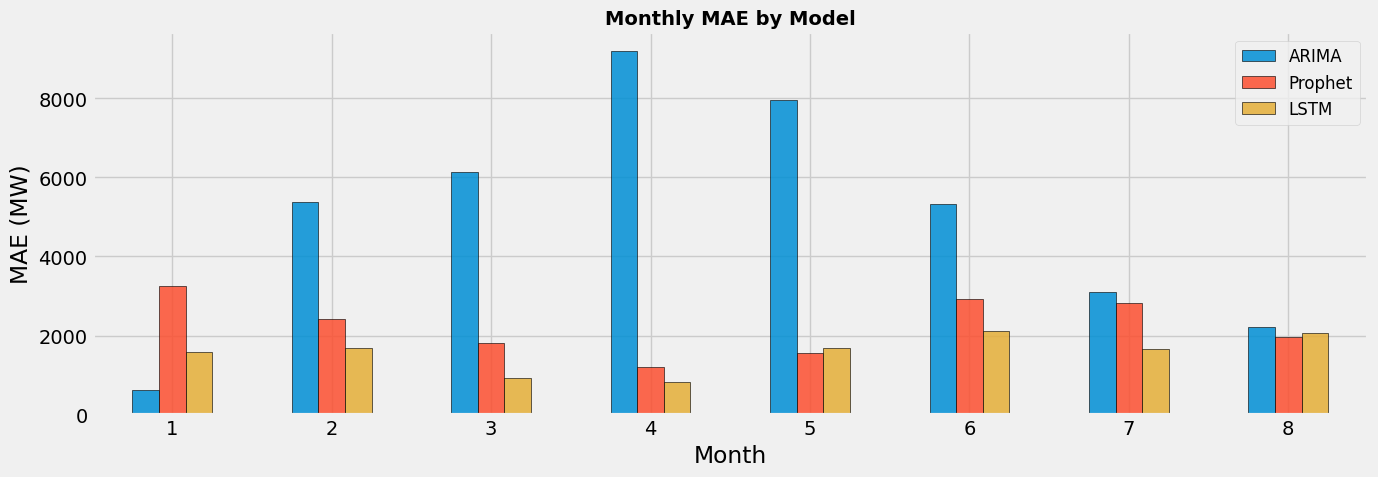

In [4]:
common_start = lstm_r.index.min()
common_end = lstm_r.index.max()

def monthly_mae(results_df, start, end):
    subset = results_df[(results_df.index >= start) & (results_df.index <= end)]
    subset['month'] = subset.index.month
    return subset.groupby('month').apply(
        lambda x: np.mean(np.abs(x['actual'] - x['predicted']))
    )

arima_monthly = monthly_mae(arima_r, common_start, common_end)
prophet_monthly = monthly_mae(prophet_r, common_start, common_end)
lstm_monthly = monthly_mae(lstm_r, common_start, common_end)

monthly_df = pd.DataFrame({
    'ARIMA': arima_monthly,
    'Prophet': prophet_monthly,
    'LSTM': lstm_monthly
})

monthly_df.plot(kind='bar', figsize=(14, 5), edgecolor='black', alpha=0.85)
plt.title('Monthly MAE by Model', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('MAE (MW)')
plt.xticks(rotation=0)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

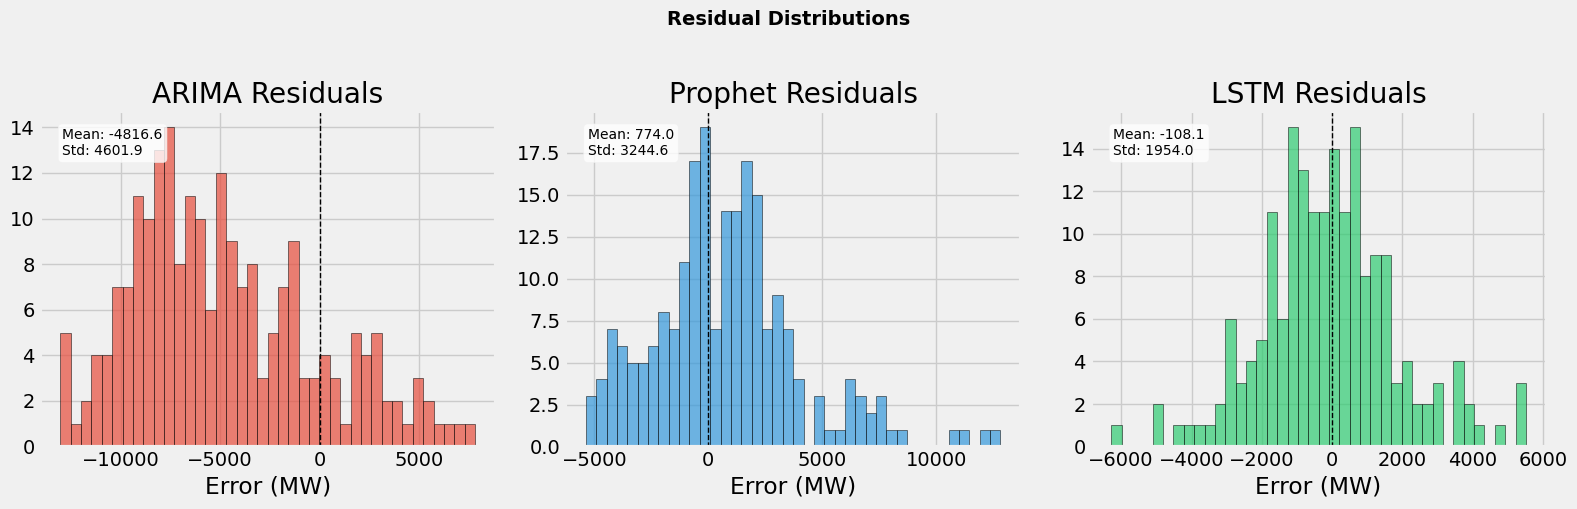

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_data = [
    ('ARIMA', arima_r),
    ('Prophet', prophet_r),
    ('LSTM', lstm_r)
]

for i, (name, data) in enumerate(models_data):
    residuals = data['actual'] - data['predicted']
    axes[i].hist(residuals, bins=40, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[i].set_title(f'{name} Residuals')
    axes[i].set_xlabel('Error (MW)')
    mean_r = residuals.mean()
    std_r = residuals.std()
    axes[i].text(0.05, 0.95, f'Mean: {mean_r:.1f}\nStd: {std_r:.1f}',
                 transform=axes[i].transAxes, verticalalignment='top',
                 fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Residual Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
best_model = metrics.loc[metrics['MAE'].idxmin(), 'model']

print("=" * 60)
print("       ENERGY CONSUMPTION FORECASTING — FINAL RESULTS")
print("=" * 60)
print(metrics.to_string(index=False))
print("=" * 60)
print(f"\nBest Model (by MAE): {best_model}")
print("\nKey Insights:")
print("- ARIMA: Simple baseline, captures trend but misses complex seasonality")
print("- Prophet: Strong seasonality handling, holiday effects included")
print("- LSTM: Learns nonlinear patterns from raw sequences")

       ENERGY CONSUMPTION FORECASTING — FINAL RESULTS
          model         MAE        RMSE      MAPE
 ARIMA(3, 1, 3) 5837.345039 6654.216152 19.991757
Prophet (Tuned) 2461.389078 3328.249718  7.412590
 LSTM (PyTorch) 1484.174824 1951.699221  4.754864

Best Model (by MAE): LSTM (PyTorch)

Key Insights:
- ARIMA: Simple baseline, captures trend but misses complex seasonality
- Prophet: Strong seasonality handling, holiday effects included
- LSTM: Learns nonlinear patterns from raw sequences
